In [10]:
from model_train_for_presentation import train_logistic_regression_model, train_lasso_logistic_regression_model
import itertools
import statsmodels.api as sm
import pandas as pd



# Full Model:


In [11]:

all_stats = [
    "AdjOE", "AdjDE", "EFG%", "EFGD%", "TOR", "TORD",
    "ORB", "DRB", "ADJ T", "WAB"
]

# Full Models
log_model_all, log_features_all, log_summary_df_all = train_logistic_regression_model(all_stats)
print(log_model_all.summary())
# print(log_summary_df_all)

Optimization terminated successfully.
         Current function value: 0.495426
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1064
Model:                          Logit   Df Residuals:                     1053
Method:                           MLE   Df Model:                           10
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2847
Time:                        18:02:03   Log-Likelihood:                -527.13
converged:                       True   LL-Null:                       -736.97
Covariance Type:            nonrobust   LLR p-value:                 6.119e-84
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0856      0.076     -1.125      0.261      -0.235       0.064
AdjOE_diff     0.1746      0.

In [12]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, log_loss
from model_train_for_presentation import create_diff
from sklearn.model_selection import train_test_split

df = pd.read_csv("../training_data/training_data.csv")
stats_list = [
        "AdjOE", "AdjDE", "EFG%", "EFGD%", "TOR", "TORD",
        "ORB", "DRB", "ADJ T", "WAB"
    ]
training_df = create_diff(df, stats_list)

X = training_df.drop("y", axis=1)
y = training_df["y"]

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80/20 split
    random_state=42,
    stratify=y            # important for classification
)

# Make sure columns match training
X_test_sm = sm.add_constant(X_test)

# Predicted probabilities
y_prob_log = log_model_all.predict(X_test_sm)

# Convert to class predictions (threshold = 0.5)
y_pred_log = (y_prob_log > 0.5).astype(int)

# Metrics
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc_roc = roc_auc_score(y_test, y_prob_log)
brier = brier_score_loss(y_test, y_prob_log)
logloss = log_loss(y_test, y_prob_log)

print("=== Logistic (All Variables) ===")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")
print(f"Brier Score: {brier}")
print(f"Log Loss: {logloss}")

=== Logistic (All Variables) ===
Precision: 0.7075471698113207
Recall: 0.7281553398058253
F1 Score: 0.7177033492822966
AUC-ROC: 0.8127096204766109
Brier Score: 0.17671921567270257
Log Loss: 0.5215430215167802


Confusion Matrix:
[[79 31]
 [28 75]]


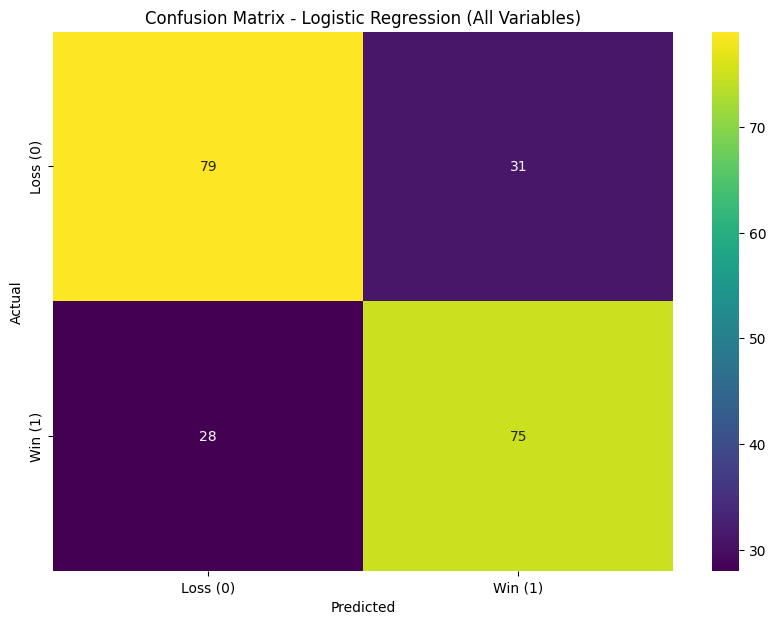

In [13]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(cm)

#plot 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=["Loss (0)", "Win (1)"], yticklabels=["Loss (0)", "Win (1)"])
plt.title("Confusion Matrix - Logistic Regression (All Variables)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Reduced Model 1


In [14]:

reduced_stats = ["AdjOE", "AdjDE", "DRB", "WAB"]
#Reduce Logit
logit_model_reduced, log_features_reduced, log_summary_reduced = train_logistic_regression_model(reduced_stats)
print(logit_model_reduced.summary())

Optimization terminated successfully.
         Current function value: 0.498051
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1064
Model:                          Logit   Df Residuals:                     1059
Method:                           MLE   Df Model:                            4
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2809
Time:                        18:02:03   Log-Likelihood:                -529.93
converged:                       True   LL-Null:                       -736.97
Covariance Type:            nonrobust   LLR p-value:                 2.525e-88
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0831      0.075     -1.103      0.270      -0.231       0.065
AdjOE_diff     0.1789      0.

# Lasso 1


In [15]:
default_stats = [
    "AdjOE", "AdjDE", "EFG%", "EFGD%", "TOR", "TORD",
    "ORB", "DRB", "ADJ T", "WAB"
]
lasso_model, selected_features, best_C = train_lasso_logistic_regression_model(
    default_stats,
    verbose=True
)

print("Final selected features:", selected_features)
selected_stats = [f.replace("_diff", "") for f in selected_features]

logit_model, _, summary = train_logistic_regression_model(selected_stats)
print(logit_model.summary())

Running GridSearch for C...
Best CV score: -0.5036
Chosen C (1-SE rule): 0.0112

Selected Features:
AdjOE_diff: 0.1144
AdjDE_diff: -0.1295
DRB_diff: 0.0116
Final selected features: ['AdjOE_diff', 'AdjDE_diff', 'DRB_diff']
Optimization terminated successfully.
         Current function value: 0.503582
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1064
Model:                          Logit   Df Residuals:                     1060
Method:                           MLE   Df Model:                            3
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2729
Time:                        18:02:12   Log-Likelihood:                -535.81
converged:                       True   LL-Null:                       -736.97
Covariance Type:            nonrobust   LLR p-value:                 7.003e-87
                 coef    std err          z 

c:\Users\joshu\PycharmProjects\March-Madness-Picks-Statistics\bart_torvik_data_model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\joshu\PycharmProjects\March-Madness-Picks-Statistics\bart_torvik_data_model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\joshu\PycharmProjects\March-Madness-Picks-Statistics\bart_torvik_data_model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, le

In [16]:
y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred_lasso)
recall = recall_score(y_test, y_pred_lasso)
f1 = f1_score(y_test, y_pred_lasso)
auc_roc = roc_auc_score(y_test, y_prob_lasso)
brier = brier_score_loss(y_test, y_prob_lasso)
logloss = log_loss(y_test, y_prob_lasso)

print("=== LASSO Logistic ===")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")
print(f"Brier Score: {brier}")
print(f"Log Loss: {logloss}")

=== LASSO Logistic ===
Precision: 0.6785714285714286
Recall: 0.7378640776699029
F1 Score: 0.7069767441860465
AUC-ROC: 0.8054721977052074
Brier Score: 0.17963704552230822
Log Loss: 0.5291142843392659


c:\Users\joshu\PycharmProjects\March-Madness-Picks-Statistics\bart_torvik_data_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\joshu\PycharmProjects\March-Madness-Picks-Statistics\bart_torvik_data_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Confusion Matrix:
[[74 36]
 [27 76]]


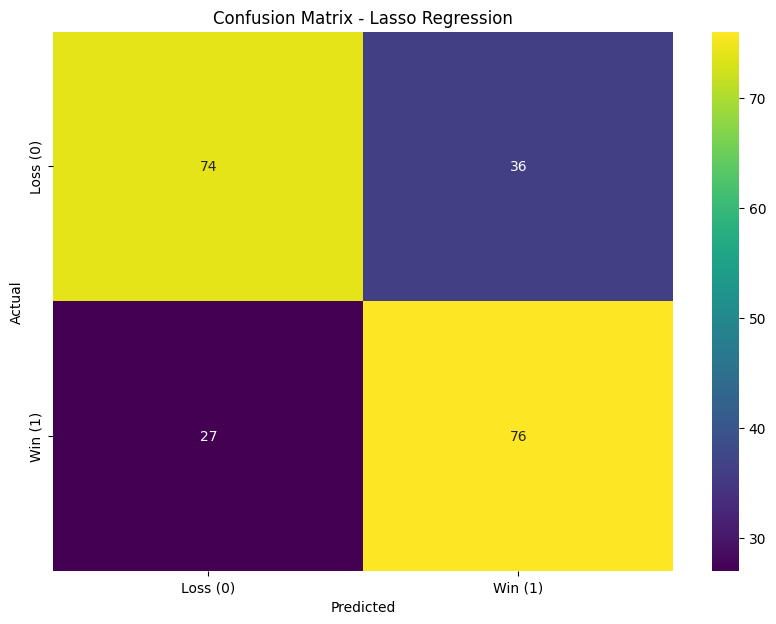

In [18]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lasso)
print("Confusion Matrix:")
print(cm)

#plot 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=["Loss (0)", "Win (1)"], yticklabels=["Loss (0)", "Win (1)"])
plt.title("Confusion Matrix - Lasso Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Best Subset

In [43]:
train_df = pd.read_csv("actual_training_data.csv")
X_full = train_df.drop(columns=["y"])
y = train_df["y"]

best_aic = float("inf")
best_model = None
best_features = None

features = X_full.columns.tolist()

for k in range(1, len(features)+1):
    for subset in itertools.combinations(features, k):
        try:
            X_subset = sm.add_constant(X_full[list(subset)])
            model = sm.Logit(y, X_subset).fit(disp=0)

            if model.aic < best_aic:
                best_aic = model.aic
                best_features = subset
                best_model = model
        except:
            continue

print("Best subset:", best_features)
print("Best AIC:", best_aic)

#show summary of best model
print(best_model.summary())

Best subset: ('AdjOE_diff', 'AdjDE_diff', 'DRB_diff', 'ADJ T_diff', 'WAB_diff')
Best AIC: 1069.3743008754468
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1064
Model:                          Logit   Df Residuals:                     1058
Method:                           MLE   Df Model:                            5
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.2826
Time:                        12:30:07   Log-Likelihood:                -528.69
converged:                       True   LL-Null:                       -736.97
Covariance Type:            nonrobust   LLR p-value:                 8.006e-88
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0897      0.076     -1.187      0.235      -0.238       0.058
AdjOE_diff     0.1793 

# Diagnostics

## Logistic ROC Curves

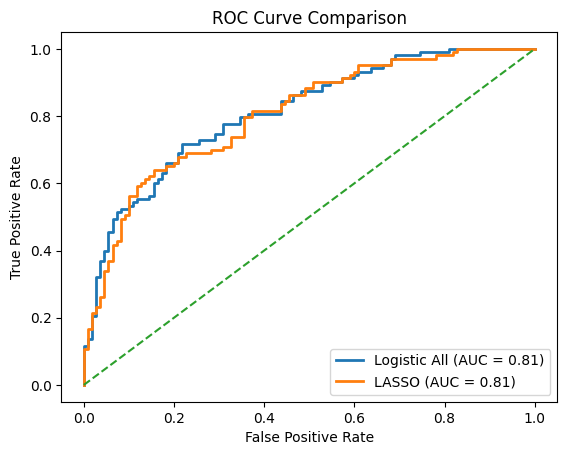

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

# # --- Tree ---
# fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob)
# plt.plot(fpr_tree, tpr_tree, lw=2, label=f'Tree (AUC = {auc(fpr_tree, tpr_tree):.2f})')

# --- Logistic (all) ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, lw=2, label=f'Logistic All (AUC = {auc(fpr_log, tpr_log):.2f})')

# --- LASSO ---
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)
plt.plot(fpr_lasso, tpr_lasso, lw=2, label=f'LASSO (AUC = {auc(fpr_lasso, tpr_lasso):.2f})')

# Baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

## Logistic Vs Tree ROC Curves

In [28]:
import joblib

clf = joblib.load("tree_depth3.pkl")

y_pred_orig = clf.predict(X_test)
y_prob_orig = clf.predict_proba(X_test)[:, 1]




In [29]:
clf_both = joblib.load("tree_depth3_both.pkl")

y_pred_both = clf_both.predict(X_test)
y_prob_both = clf_both.predict_proba(X_test)[:, 1]

In [30]:
clf_ccp = joblib.load("tree_depth3_justccp.pkl")

y_pred_ccp = clf_ccp.predict(X_test)
y_prob_ccp = clf_ccp.predict_proba(X_test)[:, 1]

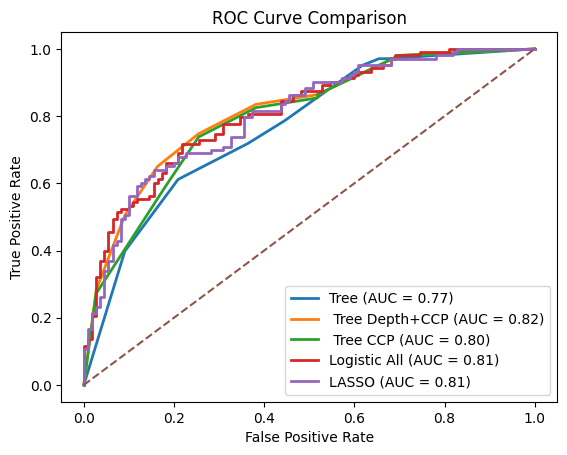

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

# --- Tree ---
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_orig)
plt.plot(fpr_tree, tpr_tree, lw=2, label=f'Tree (AUC = {auc(fpr_tree, tpr_tree):.2f})')

# --- Tree (both) ---
fpr_both, tpr_both, _ = roc_curve(y_test, y_prob_both)
plt.plot(fpr_both, tpr_both, lw=2, label=f' Tree Depth+CCP (AUC = {auc(fpr_both, tpr_both):.2f})')

# --- Tree (CCP) ---
fpr_ccp, tpr_ccp, _ = roc_curve(y_test, y_prob_ccp)
plt.plot(fpr_ccp, tpr_ccp, lw=2, label=f' Tree CCP (AUC = {auc(fpr_ccp, tpr_ccp):.2f})')

# --- Logistic (all) ---
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, lw=2, label=f'Logistic All (AUC = {auc(fpr_log, tpr_log):.2f})')

# --- LASSO ---
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)
plt.plot(fpr_lasso, tpr_lasso, lw=2, label=f'LASSO (AUC = {auc(fpr_lasso, tpr_lasso):.2f})')

# Baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import pandas as pd

results = []

def add_result(name, y_true, y_pred, y_prob):
    results.append({
        "Model": name,
        "AUC": roc_auc_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob)
    })

# Add models
add_result("Original Tree", y_test, y_pred_orig, y_prob_orig)
add_result("Tree (Both)", y_test, y_pred_both, y_prob_both)
add_result("Tree (CCP)", y_test, y_pred_ccp, y_prob_ccp)
add_result("Logistic (All)", y_test, y_pred_log, y_prob_log)
add_result("LASSO", y_test, y_pred_lasso, y_prob_lasso)

df_results = pd.DataFrame(results)
print(df_results)

            Model       AUC        F1  Precision    Recall  Log Loss     Brier
0   Original Tree  0.767299  0.682028   0.649123  0.718447  0.576066  0.197071
1     Tree (Both)  0.815755  0.740385   0.733333  0.747573  0.517692  0.172904
2      Tree (CCP)  0.797617  0.734300   0.730769  0.737864  0.532814  0.179605
3  Logistic (All)  0.812710  0.717703   0.707547  0.728155  0.521543  0.176719
4           LASSO  0.805472  0.706977   0.678571  0.737864  0.529114  0.179637
